# Impact of $A$

The goal of this notebook is to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import pyccl as ccl
import fitsio
from ulid import ULID

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Importing clustering

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

data = fitsio.FITS(clFile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_zmin0.1.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1860 (χ²/ndof = 0.0)       │              Nfcn = 322              │
│ EDM = 0.000148 (Goal: 0.0002)    │            time = 4.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.08e-3  │  0.99e-3  │  -0.08e-3  │  0.60e-3   │    0    │    1    │       │
│ 1 │ ra   │  0.09e3   │  0.28e3   │  -0.28e3   │   0.27e3   │    0    │   360   │       │
│ 2 │ dec  │    40     │    110    │    -130    │     50     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.08e-3  │  0.60e-3  │  -0.28e3  │  0.27e3   │   -130    │    50     │
│  Valid   │   True    │   True    │   False   │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────────────────┐
│     │            A           ra          dec │
├─────┼────────────────────────────────────────┤
│   A │     3.28e-07  46.67455e-3 -52.79736e-3 │
│  ra │  46.67455e-3     2.42e+05       0.01e6 │
│ dec │ -52.79736e-3       0.01e6     1.57e+05 │
└─────┴────────────────────────────────────────┘

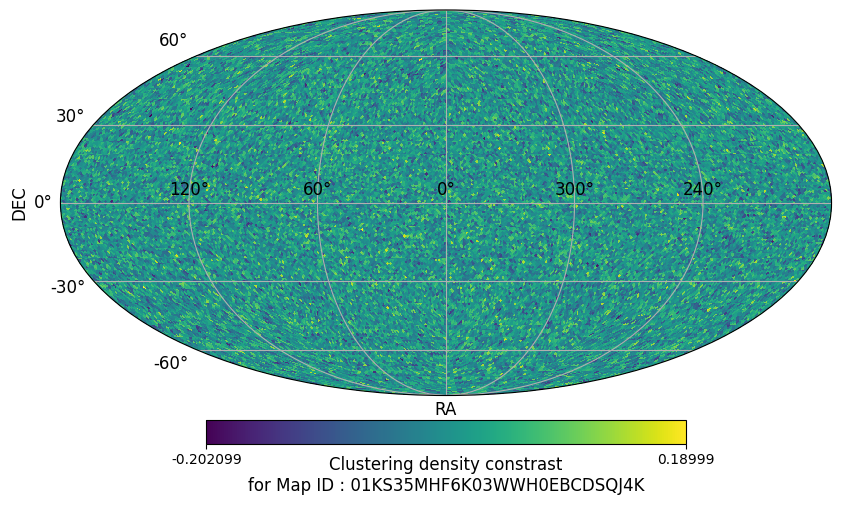

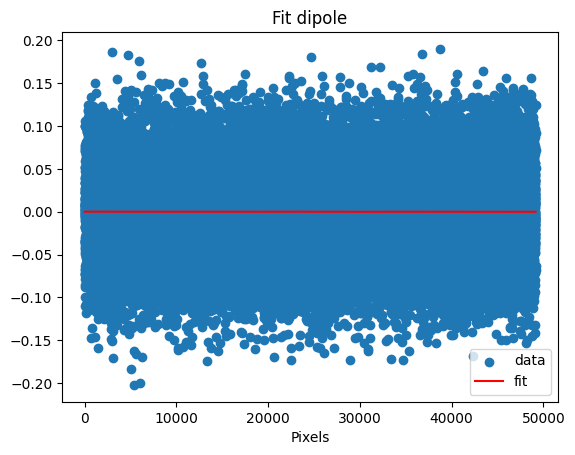

In [4]:
mapID, hpmap = data['MAPS'][0] #first clustering map
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")

init =  (0, 100, 0)
clMapper.fit_dipole("", init, fit_monop=False)

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.456e-07 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 3.46e-07 (Goal: 0.0002)    │            time = 2.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ ra   │  168.00   │   0.23    │   -0.23    │    0.23    │    0    │   360   │       │
│ 2 │ dec  │   -7.0    │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │   -0.23   │   0.23    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6     0e-6 │
│  ra │    -0e-6   0.0509    -0.03 │
│ dec │     0e-6    -0.03    0.134 │
└─────┴────────────────────────────┘

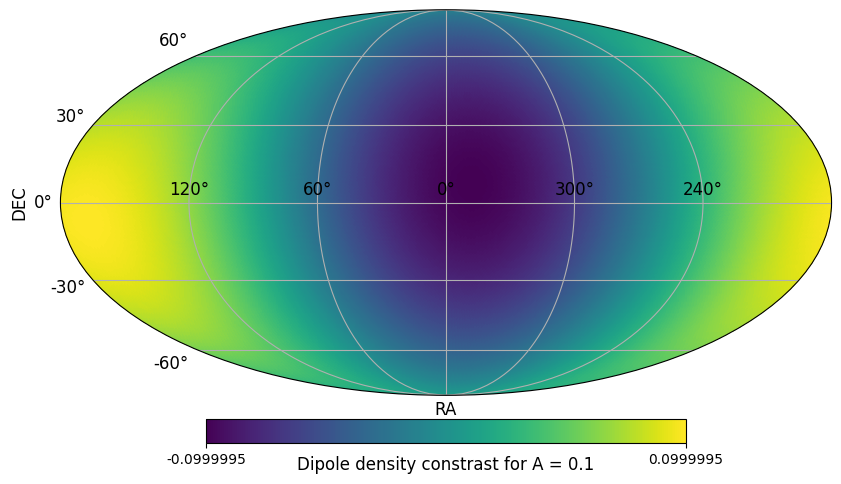

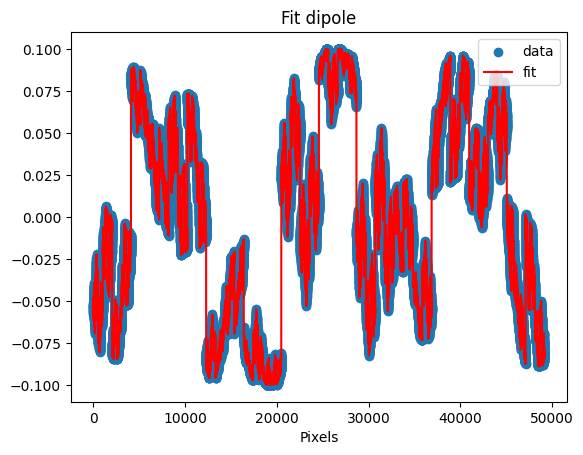

In [5]:
nest = True
A, l, b = 0.1, 168, -7
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Dipole + clustering

### Model comparison

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2947 (χ²/ndof = 0.1)       │              Nfcn = 345              │
│ EDM = 1.36e-05 (Goal: 0.0002)    │            time = 3.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  2.7e-3   │  0.4e-3   │  -0.4e-3   │   0.4e-3   │    0    │         │       │
│ 1 │ A    │999.9999996e-3│12.4039092e-3│-12.4385626e-3│0.0000004e-3│    0    │    1    │       │
│ 2 │ ra   │    171    │     8     │     -8     │     8      │    0    │   360   │       │
│ 3 │ dec  │    -3     │     8     │     -8     │     8      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.4e-3  │  0.4e-3   │-12438562.6e-9│  0.4e-9   │    -8     │     8     │    -8     │     8     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   True    │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   1.4e-07  0.001e-9 177.62e-6 175.70e-6 │
│   A │  0.001e-9  2.12e-11  0.982e-9  0.619e-9 │
│  ra │ 177.62e-6  0.982e-9      61.7        -0 │
│ dec │ 175.70e-6  0.619e-9        -0        59 │
└─────┴─────────────────────────────────────────┘

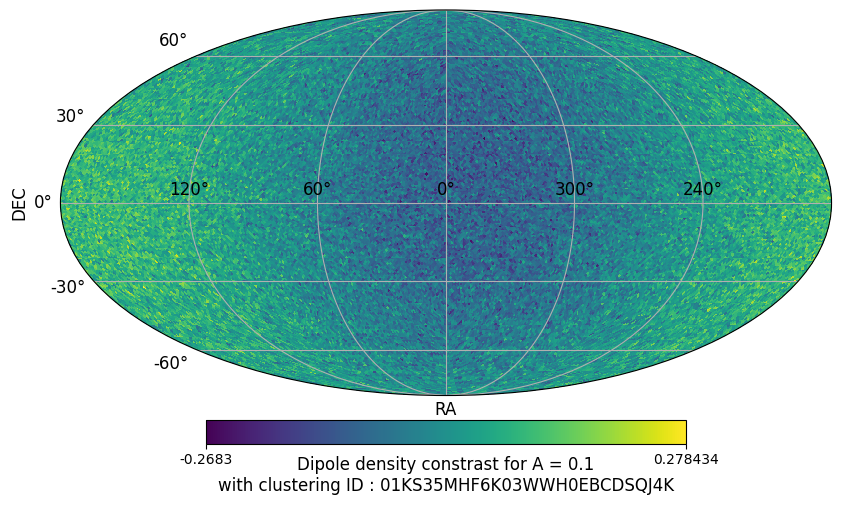

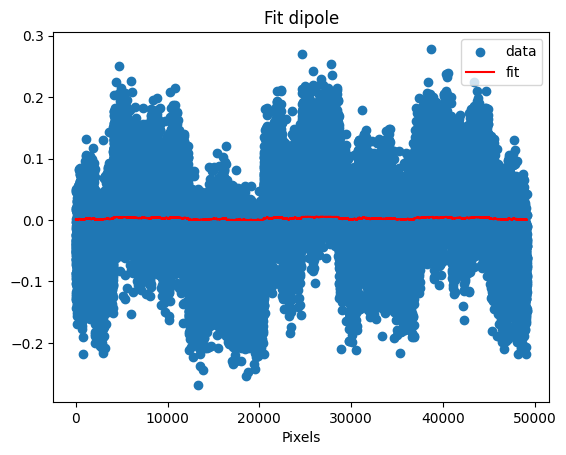

In [6]:
dipoleClMapper = dipoleMapper.add(clMapper)
dipoleClMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}\nwith clustering ID : {mapID}")

init =  (0, 1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=True)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2698 (χ²/ndof = 0.1)       │              Nfcn = 227              │
│ EDM = 2.94e-05 (Goal: 0.0002)    │            time = 2.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  15.6e-3  │  0.9e-3   │  -0.9e-3   │   0.9e-3   │    0    │    1    │       │
│ 1 │ ra   │   173.2   │    2.7    │    -2.7    │    2.7     │    0    │   360   │       │
│ 2 │ dec  │   -4.6    │    2.5    │    -2.4    │    2.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.9e-3  │  0.9e-3   │   -2.7    │    2.7    │   -2.4    │    2.5    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 8.22e-07 191.9e-6  43.9e-6 │
│  ra │ 191.9e-6     7.18       -0 │
│ dec │  43.9e-6       -0     6.06 │
└─────┴────────────────────────────┘

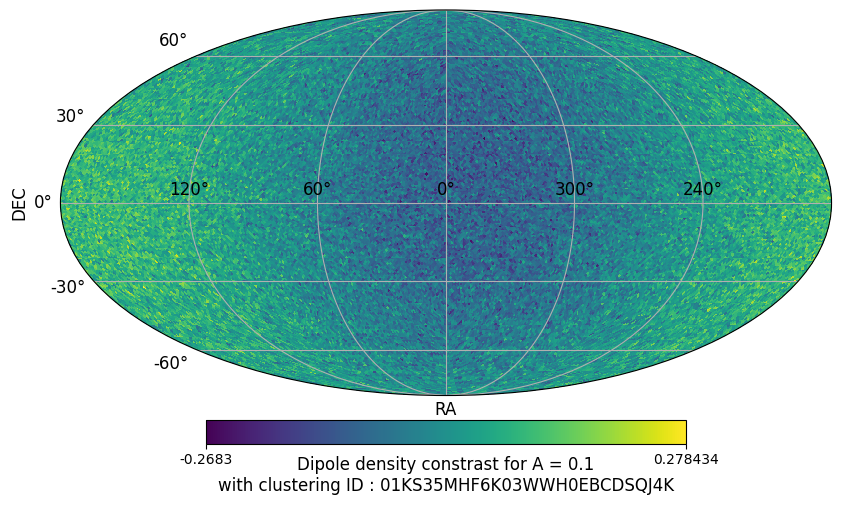

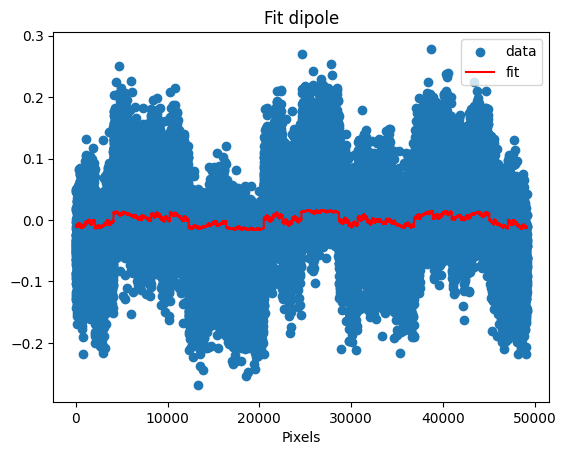

In [7]:
init =  (1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=False)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.119e+08 (χ²/ndof = 2277.1)│              Nfcn = 300              │
│ EDM = 4.78e-05 (Goal: 0.0002)    │            time = 3.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.564e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │100.092e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  167.281  │   0.005   │   -0.004   │   0.005    │    0    │   360   │       │
│ 3 │ dec  │  -6.977   │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │  -0.004   │   0.005   │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.82e-9       -0       -0 │
│   A │  0.82e-9 6.08e-11        0  0.02e-9 │
│  ra │       -0        0 2.03e-05       -0 │
│ dec │       -0  0.02e-9       -0    2e-05 │
└─────┴─────────────────────────────────────┘

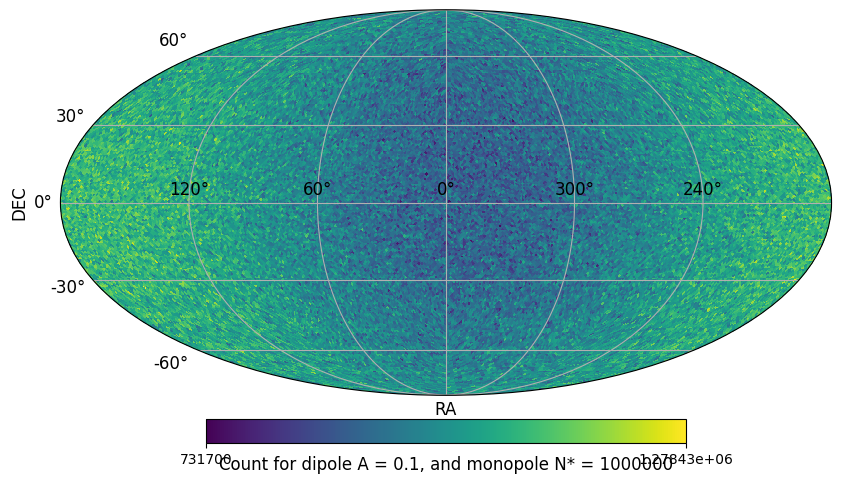

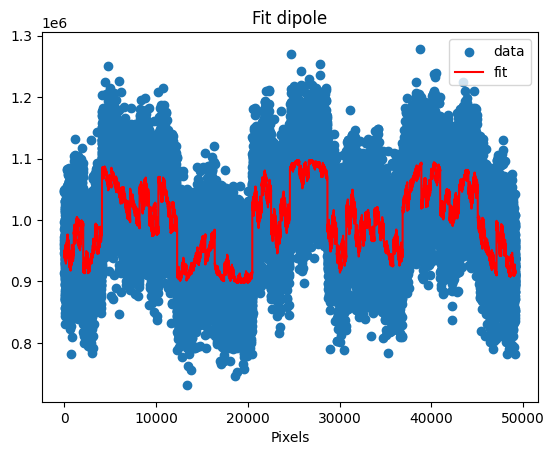

In [8]:
NSource_px_monop = apply_monopole_Mcontrast(dipoleClMapper.map, NSource_px_th)
monopMapper = CountMapper.from_map(NSource_px_monop)
monopMapper._set_suffixTextPlot(unit = f"dipole A = {A}, and monopole N* = {NSource_px_th}")

init =  (1e6, 1, 100, 0)
monopMapper.fit_dipole("", init)

### Study of $A$

In [9]:
def get_clDipMonop(A, l=l, b=b, M=NSource_px_th):
    dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
    dipoleMapper = CountMapper.from_map(dipole, nest=nest)
    dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

    dipoleClMapper = dipoleMapper.add(clMapper)
    dipoleClMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}\nwith clustering ID : {mapID}")

    monop = apply_monopole_Mcontrast(dipoleClMapper.map, M)
    monopMapper = CountMapper.from_map(monop)
    monopMapper._set_suffixTextPlot(unit = f"dipole A = {A}, and monopole N* = {NSource_px_th}")

    return monopMapper, dipoleClMapper, dipoleMapper


def get_add_param(m, A, l=l, b=b, M=NSource_px_th):
    add_param = {}
    for k, v in zip(m.values.to_dict().keys(), (M, A, l, b)): add_param[k + "_true"] = v
    return add_param


def get_compute(A, l=l, b=b, M=NSource_px_th, init=(1e6, 1, 100, 0)):
    monopMapper, dipoleClMapper, dipoleMapper = get_clDipMonop(A, l, b, M)
    m = monopMapper.fit_dipole("", init, plot_fig=False, plot_map=False, verbose=False)
    add_param = get_add_param(m, A, l, b, M)
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, monopMapper




Alist = np.logspace(-3, -1, 50)
Atest = Alist[0]

m, dic_param, monopMapper = get_compute(Atest)
dfMinuit = dic_param.copy()
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.115e+08 (χ²/ndof = 2269.1)│              Nfcn = 378              │
│ EDM = 0.00145 (Goal: 0.0002)     │            time = 3.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.572e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │ 1.362e-3  │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  104.71   │   0.33    │   -0.33    │    0.33    │    0    │   360   │       │
│ 3 │ dec  │   1.35    │   0.33    │   -0.33    │    0.33    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │   -0.33   │   0.33    │   -0.33   │   0.33    │
│  Valid   │   False   │   False   │   True    │   True    │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.02e-9    -0.00    -0.00 │
│   A │  0.02e-9 6.12e-11 -1.40e-9 -0.25e-9 │
│  ra │    -0.00 -1.40e-9    0.108     0.00 │
│ dec │    -0.00 -0.25e-9     0.00    0.108 │
└─────┴─────────────────────────────────────┘

In [10]:
for i in range(len(Alist[1:])):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    Atest = Alist[1:][i]
    m, dic_param, monopMapper = get_compute(Atest)
    dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)

print('\nFit complete')

i = 0	i = 10	i = 20	i = 30	i = 40	
Fit complete


#### Saving data

```
header_global = {'MAP_TYPE': 'Clustering', 'INJECT_DIPOLE': True, 'INJECT_MONOPOLE': True}

with fitsio.FITS(outputfile, 'rw', clobber=True) as fits: #Ouvrir le fichier en mode écriture ('rw' crée ou écrase)
    fits.write(None, header=header_global) # None car la Primary est vide de données

print("Saving complete.")
```

In [11]:
output_path = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
sufix = "Param_study"
outputfile = output_path + sufix +".fits"

dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target='A_STUDY')

All the rows already exists in A_STUDY, or empty table given. No row was saved.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:203: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)


In [13]:
data2 = fitsio.FITS(outputfile)
data2


  file: Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [16]:
dfMinuit_filtered = Table(data2['A_STUDY'].read())
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64
01KS35MHF6K03WWH0EBCDSQJ4K,997572.3171012637,1000000.0,4.50506977038458,False,0.0,inf,0.0013618013249042718,1.0,7.821325555388181e-06,False,0.0,1.0,104.70736711884734,100.0,0.329206159330397,False,0.0,360.0,1.3535265460856696,0.0,0.32907071322331516,False,-90.0,90.0,True,1000000,0.001,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.3203994606,1000000.0,4.505075806751847,False,0.0,inf,0.0014084895750335787,1.0,7.821265259881963e-06,False,0.0,1.0,108.2875426555768,100.0,0.31823443177972166,False,0.0,360.0,0.8150588616281335,0.0,0.3181633938084256,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.316919878,1000000.0,4.505069769569673,False,0.0,inf,0.0014659771255919522,1.0,7.820958547423147e-06,False,0.0,1.0,111.93426595244507,100.0,0.3057468843409765,False,0.0,360.0,0.26222371655688165,0.0,0.3057076853376397,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.2859618284,1000000.0,4.505072640487924,False,0.0,inf,0.0015353574410535969,1.0,7.82091918170684e-06,False,0.0,1.0,115.60827396207142,100.0,0.291930983163212,False,0.0,360.0,-0.296055113258775,0.0,0.29189447961470116,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.2466544495,1000000.0,4.505066590383649,False,0.0,inf,0.0016183327998381604,1.0,7.821881590264418e-06,False,0.0,1.0,119.26143292602704,100.0,0.27702140768067096,False,0.0,360.0,-0.8502952921600828,0.0,0.2769680793828132,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.2498440404,1000000.0,4.505072040250525,False,0.0,inf,0.0017163964809574824,1.0,7.821803188827491e-06,False,0.0,1.0,122.85387013268199,100.0,0.26123442298572996,False,0.0,360.0,-1.3916391528140877,0.0,0.2611376432633056,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.2942519665,1000000.0,4.505069315317087,False,0.0,inf,0.0018311670654587503,1.0,7.821740444205276e-06,False,0.0,1.0,126.34343937066464,100.0,0.24491752595001515,False,0.0,360.0,-1.9119025047162181,0.0,0.24476500343954022,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.2871142818,1000000.0,4.505072040250525,False,0.0,inf,0.001964324536113537,1.0,7.821619539650354e-06,False,0.0,1.0,129.6956296516929,100.0,0.22838611232712935,False,0.0,360.0,-2.4044262724670946,0.0,0.22817259066612205,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997572.290150718,1000000.0,4.5050666379975155,False,0.0,inf,0.002117427697103765,1.0,7.820977560862516e-06,False,0.0,1.0,132.8820278959593,100.0,0.21193299665340248,False,0.0,360.0,-2.8634406358186664,0.0,0.2116563419275359,False,-90.0,90.0,True,1000000,0.0021209508879201904,168,-7


#### Plotting graphs

Saving Cluster_A_study_val in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_val.pdf


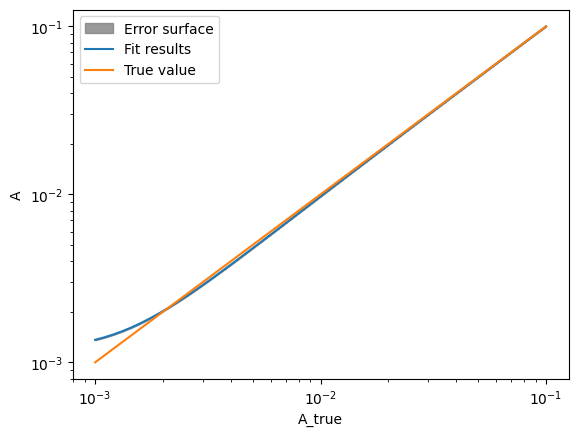

In [39]:
y_inf = dfMinuit_filtered["A"] - dfMinuit_filtered["A_err"]
y_sup = dfMinuit_filtered["A"] + dfMinuit_filtered["A_err"]
plt.fill_between(dfMinuit_filtered["A_true"], y_inf, y_sup, alpha=0.8, color='grey', label="Error surface")
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A"], label="Fit results")
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_true"], label="True value")
plt.xlabel('A_true')
plt.ylabel('A')
plt.xscale('log')
plt.yscale('log')
plt.legend();

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_val"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_err in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_err.pdf


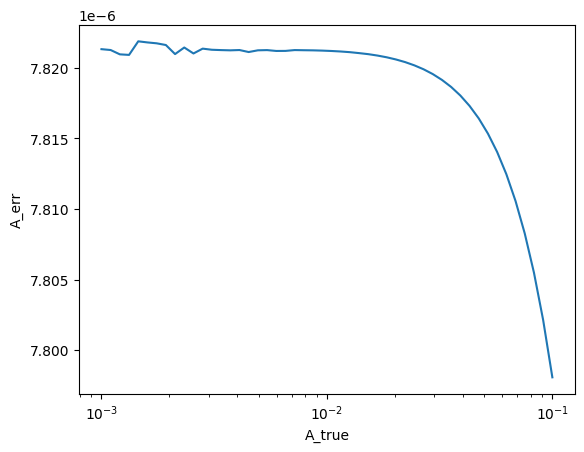

In [40]:
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_err"], label="Fit error")
plt.xlabel('A_true')
plt.ylabel('A_err')
plt.xscale('log');

utput_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_err"
get_savefig(plt, output_path, sufix)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1873 (χ²/ndof = 0.0)       │              Nfcn = 693              │
│ EDM = 4.15e-06 (Goal: 0.0002)    │           time = 11.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  0.23e-3  │  0.30e-3  │  -0.23e-3  │  0.30e-3   │    0    │         │       │
│ 1 │ A    │999.9999992e-3│846.5457155e-3│-999.9999992e-3│0.0000008e-3│    0    │    1    │       │
│ 2 │ ra   │    160    │    70     │    -160    │    200     │    0    │   360   │       │
│ 3 │ dec  │    -10    │    60     │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.23e-3  │  0.30e-3  │-999999999.2e-9│  0.8e-9   │  -0.16e3  │  0.20e3   │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │    8.95e-08      0.2e-9 -1.33916e-3 -1.86966e-3 │
│   A │      0.2e-9    3.13e-09  -3.5759e-6  -7.7792e-6 │
│  ra │ -1.33916e-3  -3.5759e-6    5.06e+03        -0e3 │
│ dec │ -1.86966e-3  -7.7792e-6        -0e3    4.59e+03 │
└─────┴─────────────────────────────────────────────────┘

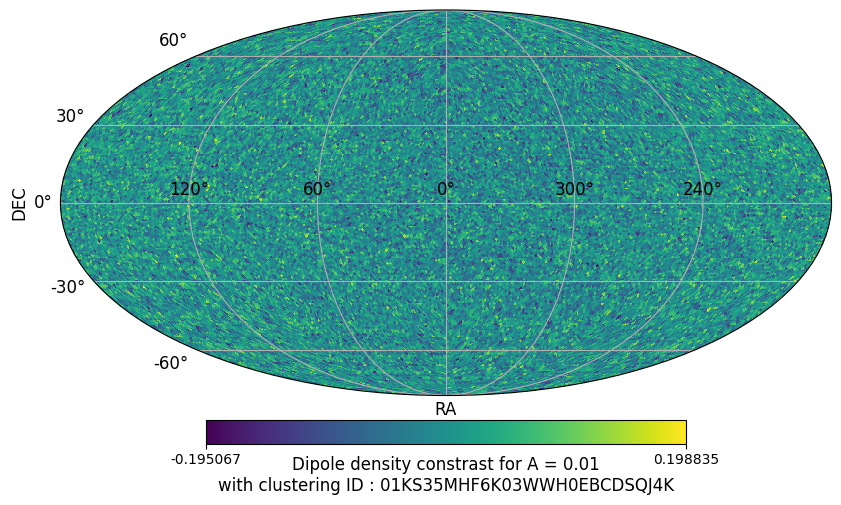

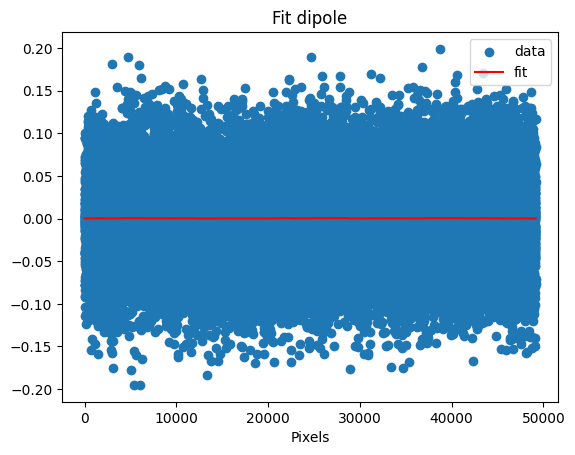

In [19]:
init =  (0, 1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=True)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.119e+08 (χ²/ndof = 2277.1)│              Nfcn = 300              │
│ EDM = 4.78e-05 (Goal: 0.0002)    │            time = 2.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.564e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │100.092e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  167.281  │   0.005   │   -0.004   │   0.005    │    0    │   360   │       │
│ 3 │ dec  │  -6.977   │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │  -0.004   │   0.005   │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.82e-9       -0       -0 │
│   A │  0.82e-9 6.08e-11        0  0.02e-9 │
│  ra │       -0        0 2.03e-05       -0 │
│ dec │       -0  0.02e-9       -0    2e-05 │
└─────┴─────────────────────────────────────┘

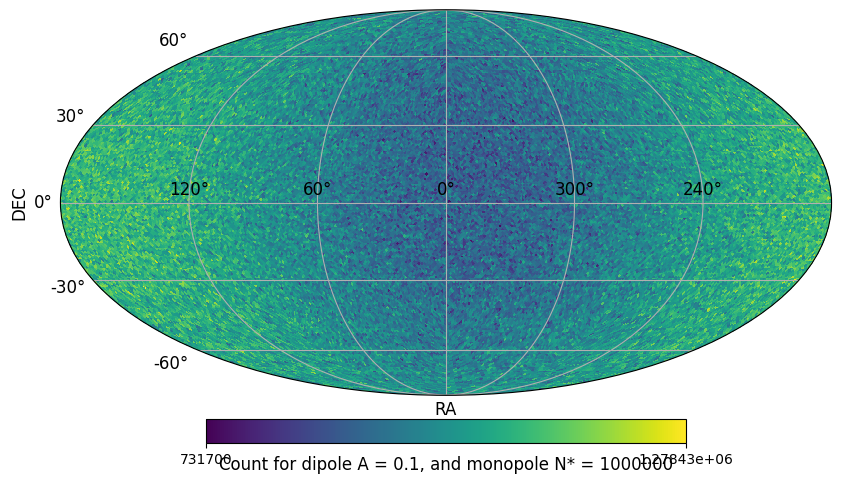

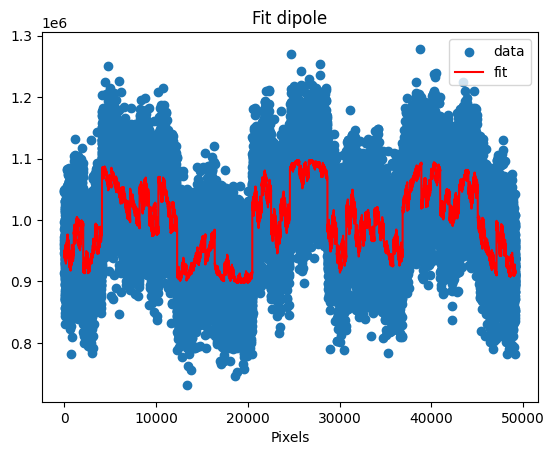

In [58]:
monopMapper, dipoleClMapper, dipoleMapper = get_clDipMonop(1e-1)
init =  (1e6, 1, 100, 0)
monopMapper.fit_dipole("", init)

In [60]:
-6.977 + 5*0.004	

-6.957000000000001

In [59]:
167.281 + 5*0.005

167.306

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.115e+08 (χ²/ndof = 2269.3)│              Nfcn = 362              │
│ EDM = 0.000104 (Goal: 0.0002)    │            time = 3.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.572e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │ 9.448e-3  │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  269.31   │   0.08    │   -0.08    │    0.08    │    0    │   360   │       │
│ 3 │ dec  │   53.79   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │   -0.08   │   0.08    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.82e-9   -0.000  -0.0000 │
│   A │  0.82e-9 6.12e-11 -1.73e-9 -0.71e-9 │
│  ra │   -0.000 -1.73e-9  0.00645   0.0000 │
│ dec │  -0.0000 -0.71e-9   0.0000  0.00225 │
└─────┴─────────────────────────────────────┘

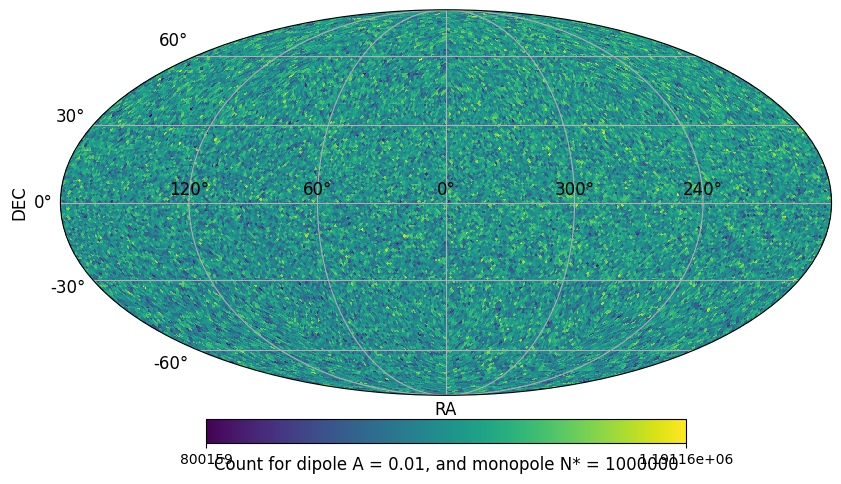

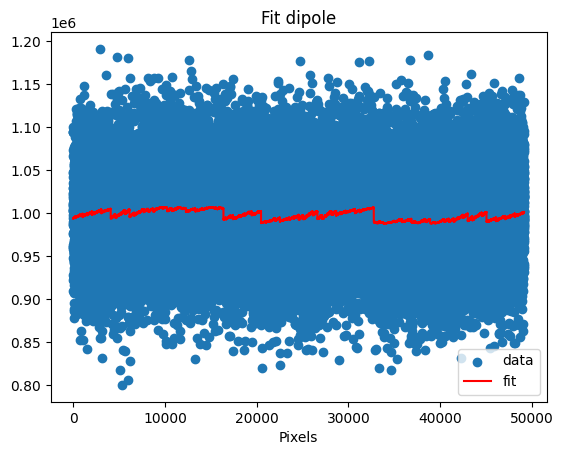

In [62]:
monopMapper, dipoleClMapper, dipoleMapper = get_clDipMonop(0.001, 264, 48)
init =  (1e6, 1, 100, 40)
monopMapper.fit_dipole("", init)

In [63]:
9.448e-3

0.009448

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1873 (χ²/ndof = 0.0)       │              Nfcn = 499              │
│ EDM = 2.55e-06 (Goal: 0.0002)    │            time = 5.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  0.17e-3  │  0.25e-3  │  -0.17e-3  │  0.25e-3   │    0    │         │       │
│ 1 │ A    │999.999999967e-3│947.844260445e-3│-999.999999967e-3│0.000000033e-3│    0    │    1    │       │
│ 2 │ ra   │    270    │    130    │    -270    │     90     │    0    │   360   │       │
│ 3 │ dec  │    50     │    140    │    -140    │     40     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.17e-3  │  0.25e-3  │-999999999.967e-9│ 0.033e-9  │   -270    │    90     │   -140    │    40     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │   6.25e-08    0.01e-9 3.90232e-3 -173.51e-6 │
│   A │    0.01e-9   2.06e-10  601.59e-9   -0.93e-9 │
│  ra │ 3.90232e-3  601.59e-9   2.23e+04       -0e3 │
│ dec │ -173.51e-6   -0.93e-9       -0e3   7.97e+03 │
└─────┴─────────────────────────────────────────────┘

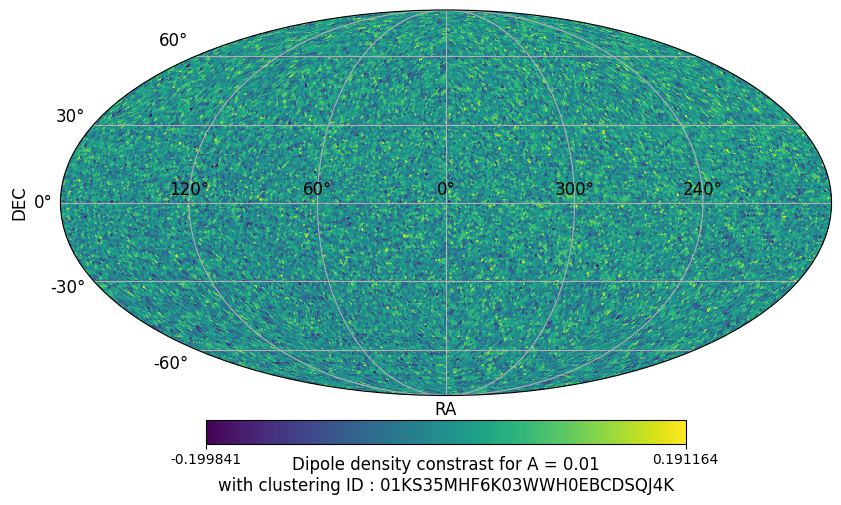

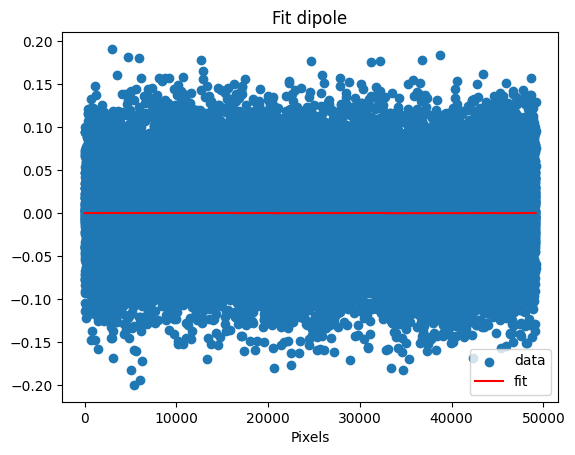

In [65]:
init =  (0, 1, 100, 40)
dipoleClMapper.fit_dipole("", init, fit_monop=True)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1872 (χ²/ndof = 0.0)       │              Nfcn = 351              │
│ EDM = 1.77e-05 (Goal: 0.0002)    │            time = 3.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.8e-3   │  0.5e-3   │  -0.5e-3   │   0.5e-3   │    0    │    1    │       │
│ 1 │ ra   │    270    │    70     │    -270    │     90     │    0    │   360   │       │
│ 2 │ dec  │    55     │    39     │    -46     │     35     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.5e-3  │  0.5e-3   │   -270    │    90     │    -46    │    35     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬──────────────────────────────────┐
│     │          A         ra        dec │
├─────┼──────────────────────────────────┤
│   A │   2.88e-07 3.49291e-3  399.73e-6 │
│  ra │ 3.49291e-3    4.8e+03     -0.1e3 │
│ dec │  399.73e-6     -0.1e3   1.73e+03 │
└─────┴──────────────────────────────────┘

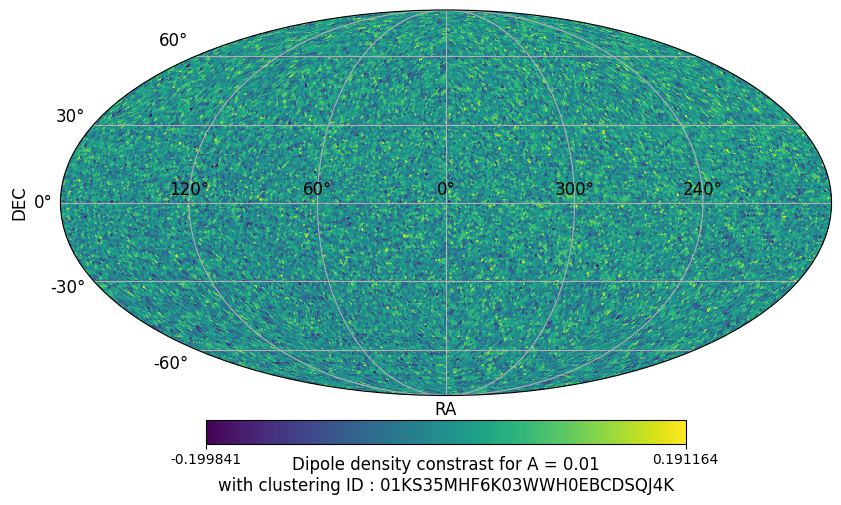

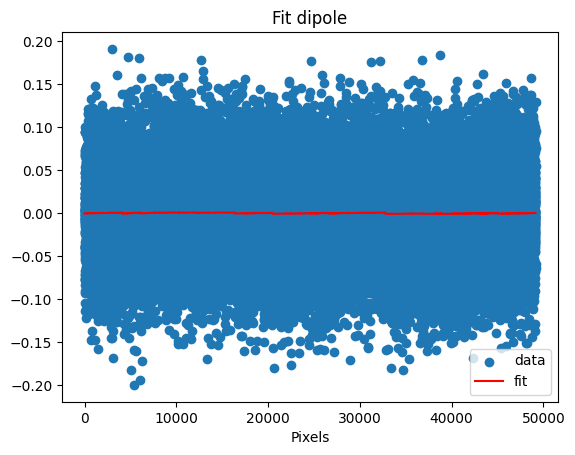

In [66]:
init =  (0, 100, 40)
dipoleClMapper.fit_dipole("", init, fit_monop=False)

In [32]:
49.856e-3

0.049856